# E-Commerce Customer Churn Analysis & Prediction

**Internship Project — Ahsan Mohamed**

This notebook analyzes customer churn in an e-commerce dataset, identifies important churn patterns, and later develops a machine-learning model for churn prediction.


## 1. Project Objective

The objective is to understand customer churn, identify behavioral factors associated with churn, and translate the findings into actionable business insights.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')


In [3]:
# Load the E Comm sheet from the supplied Excel dataset
file_path = '/Users/ahsanmohamed/EcommerceChurn/data/E Commerce Dataset.xlsx'
df = pd.read_excel(file_path, sheet_name='E Comm')

df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


## 2. Dataset Overview

The supplied dataset contains **5,630 customer records and 20 columns**.

In [4]:
# Rows, columns, and data types
print('Rows:', df.shape[0])
print('Columns:', df.shape[1])
df.info()

Rows: 5630
Columns: 20
<class 'pandas.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   str    
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   str    
 7   Gender                       5630 non-null   str    
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   str    
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   str    
 13  Number

In [5]:
# Descriptive statistics
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,5630.0,NaN,NaN,NaN,52815.5,1625.385339,50001.0,51408.25,52815.5,54222.75,55630.0
Churn,5630.0,NaN,NaN,NaN,0.168384,0.37424,0.0,0.0,0.0,0.0,1.0
Tenure,5366.0,NaN,NaN,NaN,10.189899,8.557241,0.0,2.0,9.0,16.0,61.0
PreferredLoginDevice,5630,3,Mobile Phone,2765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CityTier,5630.0,NaN,NaN,NaN,1.654707,0.915389,1.0,1.0,1.0,3.0,3.0
WarehouseToHome,5379.0,NaN,NaN,NaN,15.639896,8.531475,5.0,9.0,14.0,20.0,127.0
PreferredPaymentMode,5630,7,Debit Card,2314,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,5630,2,Male,3384,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HourSpendOnApp,5375.0,NaN,NaN,NaN,2.931535,0.721926,0.0,2.0,3.0,3.0,5.0
NumberOfDeviceRegistered,5630.0,NaN,NaN,NaN,3.688988,1.023999,1.0,3.0,4.0,4.0,6.0


## 3. Data Quality Check


In [6]:
# Missing values
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing

DaySinceLastOrder              307
OrderAmountHikeFromlastYear    265
Tenure                         264
OrderCount                     258
CouponUsed                     256
HourSpendOnApp                 255
WarehouseToHome                251
dtype: int64

In [7]:
# Duplicate checks
print('Duplicate rows:', df.duplicated().sum())
print('Duplicate Customer IDs:', df['CustomerID'].duplicated().sum())

Duplicate rows: 0
Duplicate Customer IDs: 0


### Initial findings from the supplied dataset
- Total customers: **5,630**
- Duplicate rows: **0**
- Duplicate Customer IDs: **0**
- Churned customers: **948**
- Non-churned customers: **4,682**
- Overall churn rate: **16.84%**

The dataset contains missing values in several numerical fields. These will be handled during the data-cleaning stage rather than silently dropping customer records.

Churn
0    4682
1     948
Name: count, dtype: int64
Overall churn rate: 16.84%


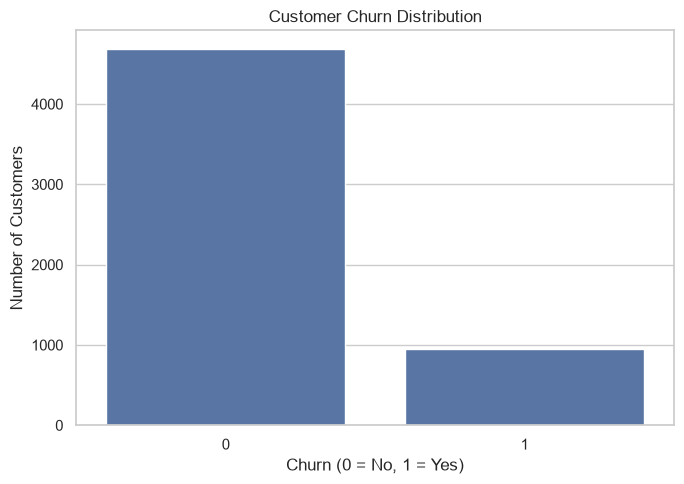

In [8]:
# Churn distribution
churn_counts = df['Churn'].value_counts().sort_index()
churn_rate = df['Churn'].mean() * 100

print(churn_counts)
print(f'Overall churn rate: {churn_rate:.2f}%')

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Churn')
plt.title('Customer Churn Distribution')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

## Step 2 — Data Cleaning.

Next we will clean the missing values, inspect categorical distributions, analyze churn against customer behavior, and calculate business KPIs before training prediction models.

In [9]:
# Check missing values
missing_values = df.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

DaySinceLastOrder              307
OrderAmountHikeFromlastYear    265
Tenure                         264
OrderCount                     258
CouponUsed                     256
HourSpendOnApp                 255
WarehouseToHome                251
dtype: int64

In [10]:
# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Check duplicate customer IDs
print("Duplicate Customer IDs:", df["CustomerID"].duplicated().sum())

Duplicate rows: 0
Duplicate Customer IDs: 0


In [11]:
# Numerical columns
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_cols:
    if col != "Churn":
        df[col] = df[col].fillna(df[col].median())

# Categorical columns
categorical_cols = df.select_dtypes(include=["object"]).columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values after cleaning:
Series([], dtype: int64)


/var/folders/sk/548pn_d15b33f36ycbvpd1p80000gn/T/ipykernel_27396/3978736324.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns


In [12]:
print("Dataset shape:", df.shape)
print("Total missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Dataset shape: (5630, 20)
Total missing values: 0
Duplicate rows: 0


# Step 3 — Exploratory Data Analysis (EDA).

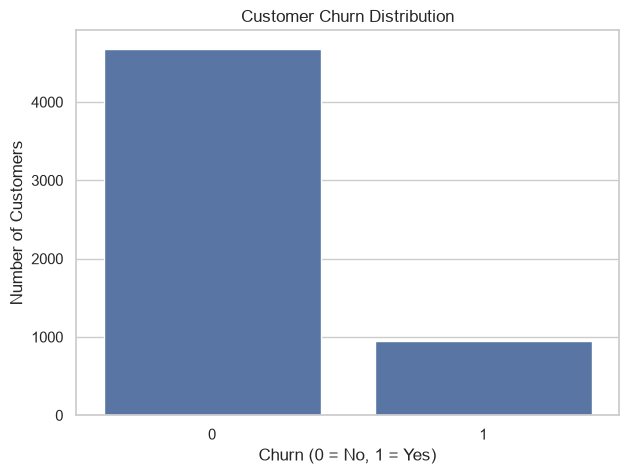

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.show()

In [14]:
churn_counts = df["Churn"].value_counts()
churn_percentages = df["Churn"].value_counts(normalize=True) * 100

print("Customer Counts:")
print(churn_counts)

print("\nCustomer Percentages:")
print(churn_percentages.round(2))

Customer Counts:
Churn
0    4682
1     948
Name: count, dtype: int64

Customer Percentages:
Churn
0    83.16
1    16.84
Name: proportion, dtype: float64


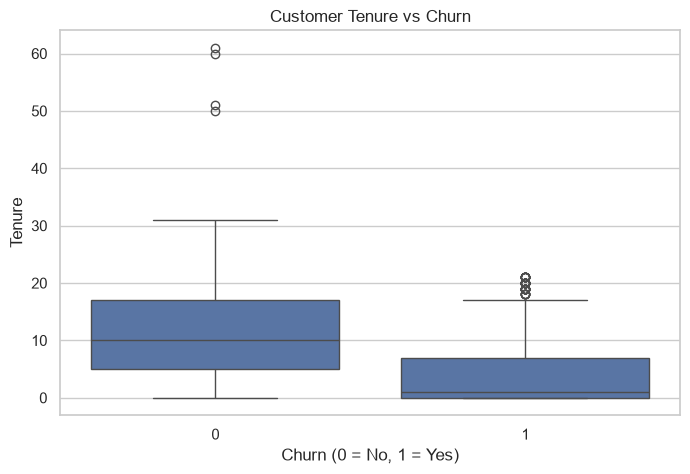

In [15]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="Tenure"
)

plt.title("Customer Tenure vs Churn")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Tenure")

plt.show()

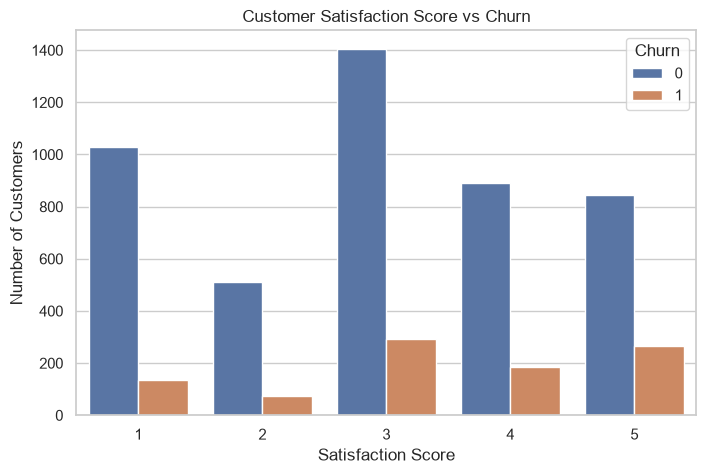

In [16]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="SatisfactionScore",
    hue="Churn"
)

plt.title("Customer Satisfaction Score vs Churn")
plt.xlabel("Satisfaction Score")
plt.ylabel("Number of Customers")

plt.show()

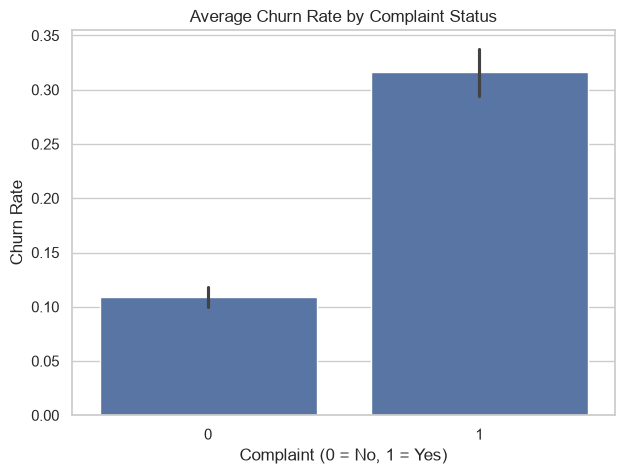

In [18]:
complaint_churn = pd.crosstab(
    df["Complain"],
    df["Churn"],
    normalize="index"
) * 100

complaint_churn.round(2)
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="Complain",
    y="Churn"
)

plt.title("Average Churn Rate by Complaint Status")
plt.xlabel("Complaint (0 = No, 1 = Yes)")
plt.ylabel("Churn Rate")

plt.show()

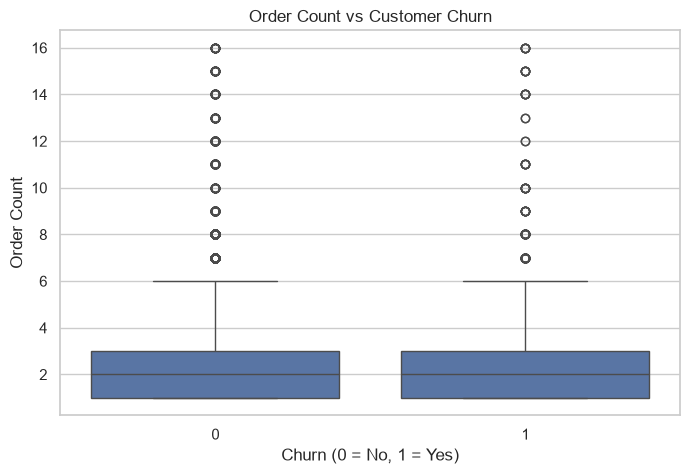

In [19]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="OrderCount"
)

plt.title("Order Count vs Customer Churn")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Order Count")

plt.show()

In [20]:
df.groupby("Churn")["OrderCount"].agg(
    ["count", "mean", "median"]
).round(2)

,count,mean,median
Churn,,,
0,4682,2.99,2.0
1,948,2.81,2.0


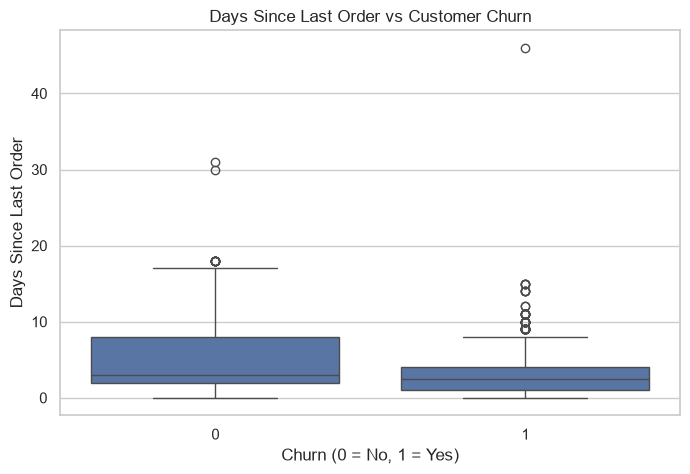

In [21]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="DaySinceLastOrder"
)

plt.title("Days Since Last Order vs Customer Churn")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Days Since Last Order")

plt.show()

In [22]:
df.groupby("Churn")["DaySinceLastOrder"].agg(
    ["count", "mean", "median"]
).round(2)

,count,mean,median
Churn,,,
0,4682,4.71,3.0
1,948,3.22,2.5


In [23]:
payment_churn = pd.crosstab(
    df["PreferredPaymentMode"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn = payment_churn.rename(
    columns={0: "Not Churned (%)", 1: "Churned (%)"}
)

payment_churn.round(2)

Churn,Not Churned (%),Churned (%)
PreferredPaymentMode,,
CC,78.39,21.61
COD,71.23,28.77
Cash on Delivery,84.56,15.44
Credit Card,87.14,12.86
Debit Card,84.62,15.38
E wallet,77.20,22.80
UPI,82.61,17.39


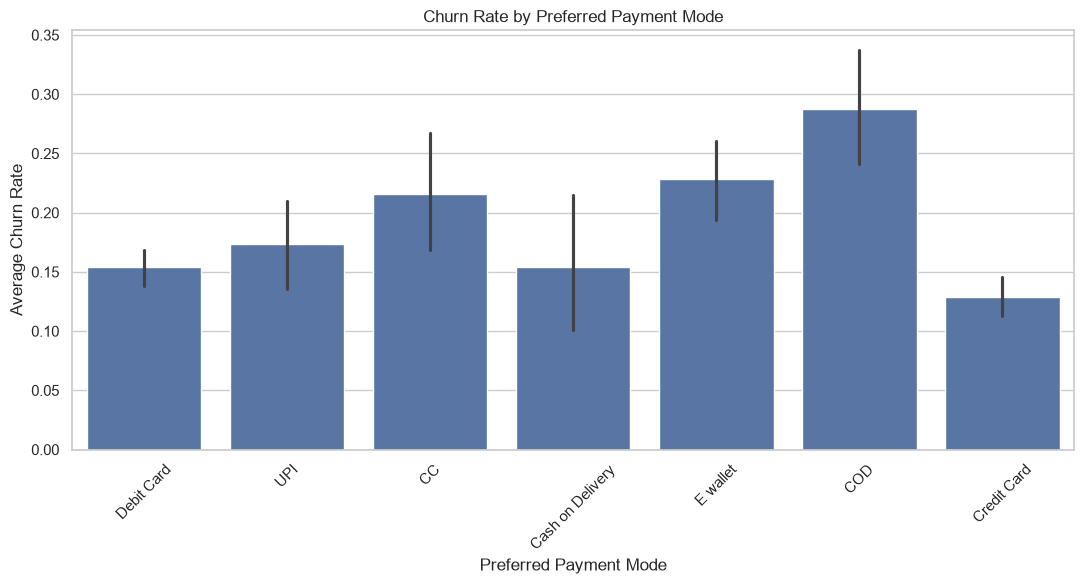

In [24]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=df,
    x="PreferredPaymentMode",
    y="Churn"
)

plt.title("Churn Rate by Preferred Payment Mode")
plt.xlabel("Preferred Payment Mode")
plt.ylabel("Average Churn Rate")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [25]:
kpi_table = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Churned Customers",
        "Active Customers",
        "Overall Churn Rate",
        "Average Tenure",
        "Average Order Count",
        "Average Satisfaction Score"
    ],
    "Value": [
        len(df),
        int(df["Churn"].sum()),
        int((df["Churn"] == 0).sum()),
        round(df["Churn"].mean() * 100, 2),
        round(df["Tenure"].mean(), 2),
        round(df["OrderCount"].mean(), 2),
        round(df["SatisfactionScore"].mean(), 2)
    ]
})

kpi_table

,Metric,Value
0,Total Customers,5630.00
1,Churned Customers,948.00
2,Active Customers,4682.00
3,Overall Churn Rate,16.84
4,Average Tenure,10.13
5,Average Order Count,2.96
6,Average Satisfaction Score,3.07


# Step 4 — Add the Business Insights section

In [26]:
# Business insight summary

insights = pd.DataFrame({
    "Area": [
        "Customer Tenure",
        "Customer Complaints",
        "Satisfaction Score"
    ],
    "Finding": [
        "Churned customers have substantially lower average tenure.",
        "Customers who complained have a higher observed churn rate.",
        "Churn varies across satisfaction levels and does not show a simple decreasing pattern."
    ],
    "Business Relevance": [
        "Newer customers may need stronger onboarding and early-retention efforts.",
        "Complaint handling may be an important area for customer-retention monitoring.",
        "Satisfaction should be analyzed together with other behavioral variables rather than used alone."
    ]
})

insights

,Area,Finding,Business Relevance
0,Customer Tenure,Churned customers have substantially lower ave...,Newer customers may need stronger onboarding a...
1,Customer Complaints,Customers who complained have a higher observe...,Complaint handling may be an important area fo...
2,Satisfaction Score,Churn varies across satisfaction levels and do...,Satisfaction should be analyzed together with ...


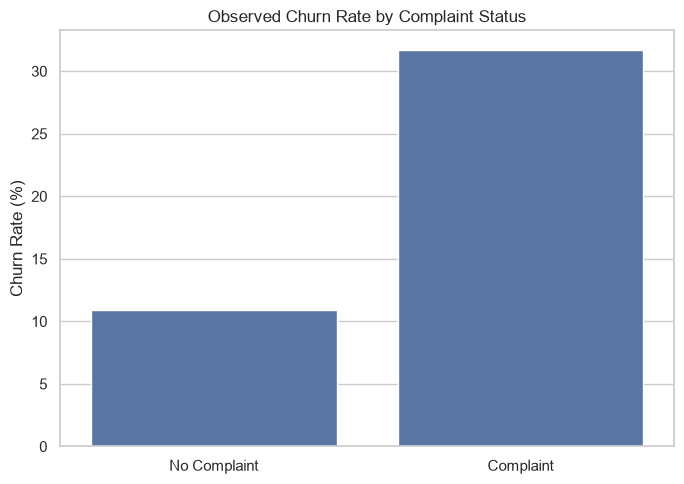

In [27]:
# Churn rate by complaint status

complaint_rate = (
    df.groupby("Complain")["Churn"]
      .mean()
      .mul(100)
      .reset_index()
)

complaint_rate["Complaint Status"] = complaint_rate["Complain"].map({
    0: "No Complaint",
    1: "Complaint"
})

plt.figure(figsize=(7, 5))

sns.barplot(
    data=complaint_rate,
    x="Complaint Status",
    y="Churn"
)

plt.title("Observed Churn Rate by Complaint Status")
plt.xlabel("")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

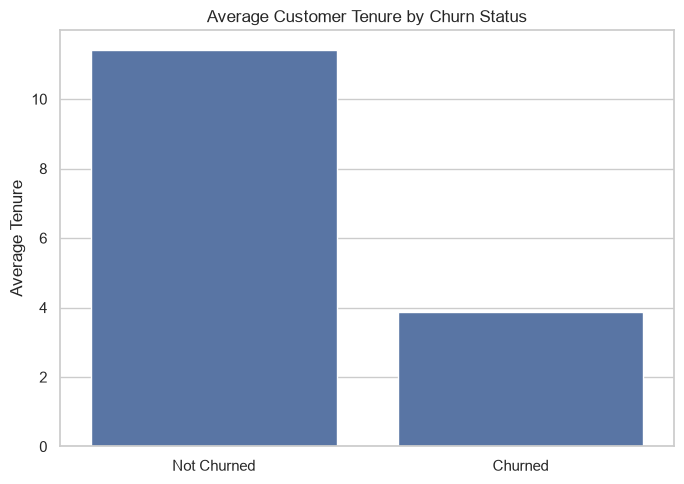

In [28]:
tenure_summary = (
    df.groupby("Churn")["Tenure"]
      .mean()
      .reset_index()
)

tenure_summary["Customer Status"] = tenure_summary["Churn"].map({
    0: "Not Churned",
    1: "Churned"
})

plt.figure(figsize=(7, 5))

sns.barplot(
    data=tenure_summary,
    x="Customer Status",
    y="Tenure"
)

plt.title("Average Customer Tenure by Churn Status")
plt.xlabel("")
plt.ylabel("Average Tenure")

plt.tight_layout()
plt.show()

# STEP 5 — MACHINE LEARNING

The goal of this step is to build classification models that predict whether a customer is likely to churn. Two models are compared: Logistic Regression and Random Forest. `CustomerID` is excluded because it is an identifier rather than a meaningful predictive feature, and `Churn` is the target variable.

In [29]:
# Step 5.1 — Prepare features and target
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

model_df = df.copy()

X = model_df.drop(columns=['Churn', 'CustomerID'])
y = model_df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numeric_features = X.select_dtypes(exclude=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

print('Training rows:', X_train.shape[0])
print('Testing rows:', X_test.shape[0])
print('Features used:', X.shape[1])


Training rows: 4504
Testing rows: 1126
Features used: 18


/var/folders/sk/548pn_d15b33f36ycbvpd1p80000gn/T/ipykernel_27396/2380273380.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object']).columns.tolist()


In [30]:
# Step 5.2 — Train Logistic Regression and Random Forest
logistic_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42))
])

random_forest_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight='balanced'
    ))
])

logistic_model.fit(X_train, y_train)
random_forest_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)
logistic_prob = logistic_model.predict_proba(X_test)[:, 1]

rf_pred = random_forest_model.predict(X_test)
rf_prob = random_forest_model.predict_proba(X_test)[:, 1]

print('Both models trained successfully.')


Both models trained successfully.


In [31]:
# Step 5.3 — Evaluate both models
def evaluate_model(name, y_true, y_pred, y_prob):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1 Score': f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_true, y_prob)
    }

results = pd.DataFrame([
    evaluate_model('Logistic Regression', y_test, logistic_pred, logistic_prob),
    evaluate_model('Random Forest', y_test, rf_pred, rf_prob)
])

results.round(4)


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7904,0.4372,0.8421,0.5755,0.8862
1,Random Forest,0.9840,0.9388,0.9684,0.9534,0.9986


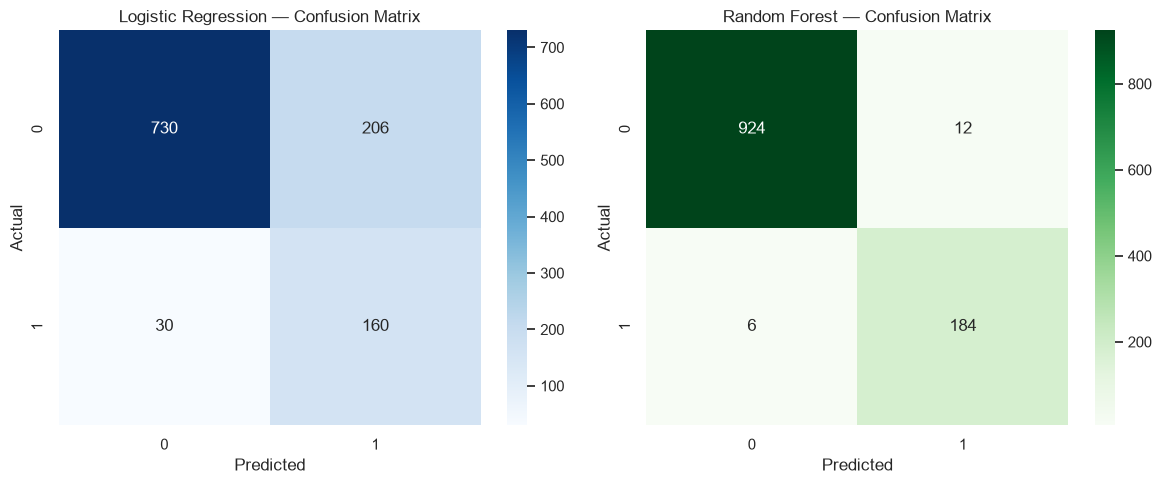

In [32]:
# Step 5.4 — Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_logistic = confusion_matrix(y_test, logistic_pred)
sns.heatmap(cm_logistic, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression — Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Random Forest — Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()



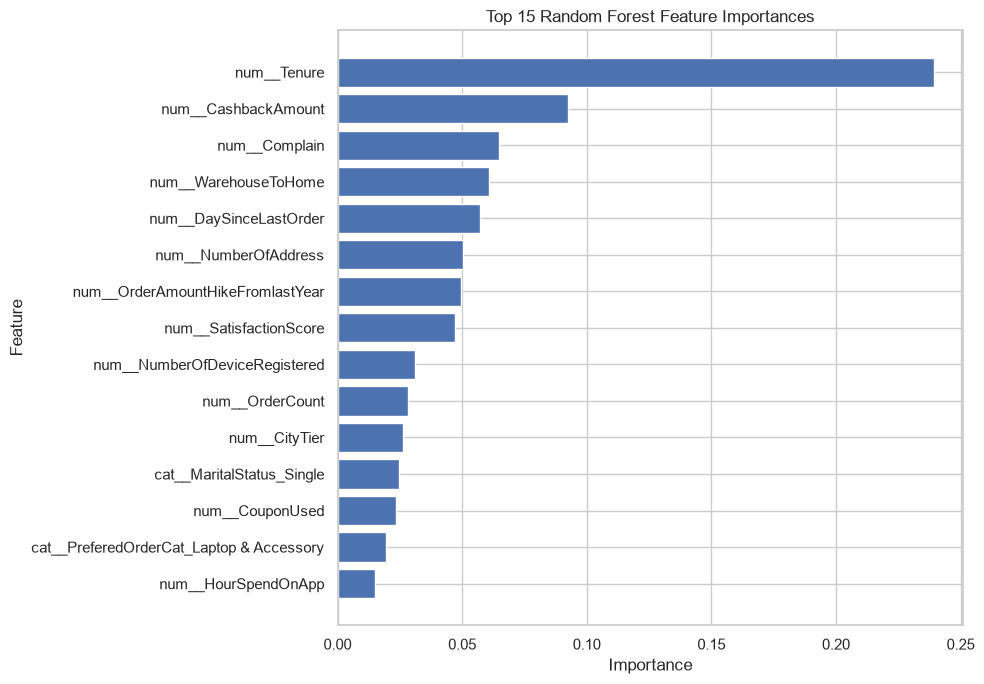

,Feature,Importance
0,num__Tenure,0.239119
12,num__CashbackAmount,0.092354
7,num__Complain,0.064784
2,num__WarehouseToHome,0.060813
11,num__DaySinceLastOrder,0.057029
6,num__NumberOfAddress,0.050138
8,num__OrderAmountHikeFromlastYear,0.049396
5,num__SatisfactionScore,0.047258
4,num__NumberOfDeviceRegistered,0.031251
10,num__OrderCount,0.028085


In [33]:
# Step 5.5 — Random Forest feature importance
rf_preprocessor = random_forest_model.named_steps['preprocessor']
rf_classifier = random_forest_model.named_steps['classifier']

feature_names = rf_preprocessor.get_feature_names_out()
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_classifier.feature_importances_
}).sort_values('Importance', ascending=False)

top_features = importance_df.head(15).sort_values('Importance')

plt.figure(figsize=(10, 7))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.title('Top 15 Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

importance_df.head(15)


## Model interpretation

The evaluation metrics above should be used together rather than relying on accuracy alone. Because churn is the business outcome of interest, recall and F1-score are particularly useful for understanding how well the model identifies churned customers. ROC-AUC provides an additional measure of ranking/discrimination performance.

Random Forest feature importance indicates which variables contributed most to the model's predictions. These are model-based associations, not proof that a variable causes churn.